In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report 
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cancer dataset.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df = df.drop(['id','Unnamed: 32'], axis = 'columns')

In [6]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


<AxesSubplot:xlabel='diagnosis', ylabel='count'>

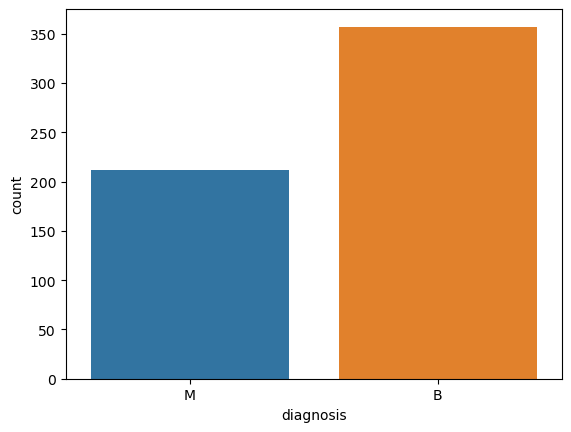

In [7]:
sns.countplot(x='diagnosis',data=df)

In [8]:
df.diagnosis.value_counts()

B    357
M    212
Name: diagnosis, dtype: int64

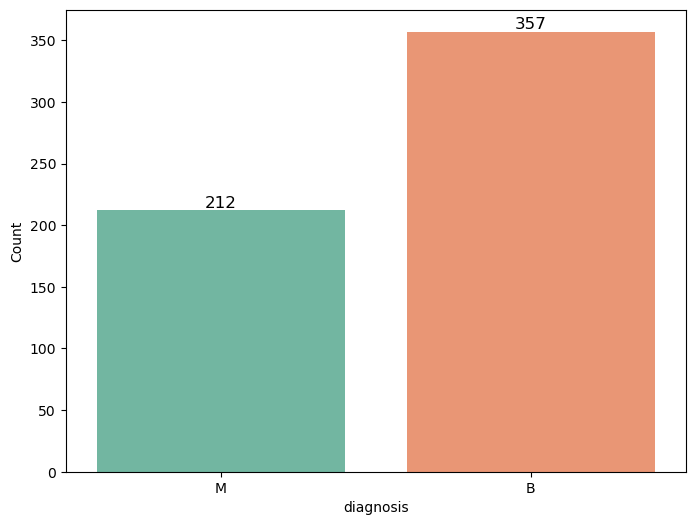

In [9]:
# Create the countplot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='diagnosis', data=df, palette='Set2')

# Annotate the bars with their respective counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)

# Optionally, you can set the y-axis label
plt.ylabel('Count')

# Show the plot
plt.show()


In [10]:
x = df.drop('diagnosis',axis=1)

In [11]:
y = df[['diagnosis']]

# Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42, test_size=.30)

In [13]:
ytest

,diagnosis
204,B
70,M
131,M
431,B
540,B
...,...
69,B
542,B
176,B
501,M


In [14]:
ytest.shape

(171, 1)

In [15]:
xtest.shape

(171, 30)

# Test and Validation

In [16]:
x_test, x_val, y_test, y_val = train_test_split(xtest, ytest, random_state=42, test_size=.50)
x_test.shape #15% of total data

(85, 30)

In [17]:
x_val.shape #15% of total data ; for hyper param tuning

(86, 30)

# Step 3: Decision Tree model and evaluation

In [18]:
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(xtrain, ytrain)
y_pred_dt = dt_model.predict(xtest)

In [19]:
y_pred_dt

array(['B', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M',
       'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B'], dtype=object)

# Evaluate Decision Tree model performance

In [20]:
print("Decision Tree Model Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt), '\n')
print("Classification Report:")
print(classification_report(ytest, y_pred_dt))

Decision Tree Model Performance:
Accuracy: 0.935672514619883 

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.94      0.95       108
           M       0.89      0.94      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



# Step 4: Random Forest model and evaluation

In [21]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(xtrain, ytrain)
y_pred_rf = rf_model.predict(xtest)

In [22]:
y_pred_rf

array(['B', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M',
       'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B'], dtype=object)

# Evaluate Random Forest model performance

In [23]:
print("\nRandom Forest Model Performance:") 
print("Accuracy:", accuracy_score(ytest, y_pred_rf), '\n') 
print("Classification Report:") 
print(classification_report(ytest, y_pred_rf)) 


Random Forest Model Performance:
Accuracy: 0.9707602339181286 

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.98       108
           M       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



# Pre - Pruning for Cost Complexity

# Initialized Hyperparameters

In [24]:
# Define hyperparameters for Decision Tree 
dt_params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 2,4,6,8,10,12, 15,20,25,28],
    'min_samples_split': [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [1,2,3,4,5]
}


#Define hyperparameters for Random Forest
rf_params = {
    'n_estimators': [101, 151, 201, 251, 301],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2,4,6,8,10,15,20,25,28],
    'min_samples_split': [2,3,4,5,6,7,810],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [25]:
# Perform Grid Search for Decision Tree
dt_grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state=42),
                              param_grid = dt_params, cv=5)
dt_grid_search.fit(xtrain, ytrain)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 4, 6, 8, 10, 12, 15, 20, 25,
                                       28],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'splitter': ['best', 'random']})

In [26]:
dt_grid_search.cv_results_

{'mean_fit_time': array([0.00737796, 0.00232687, 0.00727015, ..., 0.00233984, 0.00674486,
        0.00205488]),
 'std_fit_time': array([0.00086743, 0.00037113, 0.00050477, ..., 0.00071817, 0.00067538,
        0.00070358]),
 'mean_score_time': array([0.00295997, 0.00181251, 0.00238075, ..., 0.00206141, 0.00234179,
        0.0021275 ]),
 'std_score_time': array([0.00050689, 0.00068877, 0.00052636, ..., 0.000277  , 0.00067922,
        0.00020129]),
 'param_criterion': masked_array(data=['gini', 'gini', 'gini', ..., 'entropy', 'entropy',
                    'entropy'],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_depth': masked_array(data=[None, None, None, ..., 28, 28, 28],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_min_samples_leaf': masked_array(data=[1, 1, 1, ..., 5, 5, 5],
              mask=[False, False, False, ..

In [31]:
tuning_result_dt_gs = pd.DataFrame(dt_grid_search.cv_results_)
tuning_result_dt_gs.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007378,0.000867,0.002960,0.000507,gini,None,1,2,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.911392,0.909620,0.016292,1569
1,0.002327,0.000371,0.001813,0.000689,gini,None,1,2,random,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9375,0.9000,0.9625,0.911392,0.949367,0.932152,0.023284,334
2,0.007270,0.000505,0.002381,0.000526,gini,None,1,3,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.911392,0.909620,0.016292,1569
3,0.002557,0.000085,0.002038,0.000046,gini,None,1,3,random,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9500,0.9000,0.9625,0.924051,0.949367,0.937184,0.022400,46
4,0.007146,0.000710,0.002563,0.000509,gini,None,1,4,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.924051,0.912152,0.017321,1381


In [32]:
tuning_result_dt_gs.shape

(1980, 18)

In [33]:
dt_grid_search.best_params_ #clf = dt_grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'min_samples_leaf': 1,
 'min_samples_split': 9,
 'splitter': 'random'}

In [34]:
tuning_result_dt_gs.sort_values('rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1275,0.002286,0.000403,0.002412,0.000205,entropy,6,1,9,random,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.9375,0.9500,0.9375,0.949367,0.936709,0.942215,0.006108,1
1293,0.002794,0.000421,0.002009,0.000008,entropy,6,2,9,random,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.9375,0.9375,0.9500,0.949367,0.936709,0.942215,0.006108,1
1190,0.006567,0.000845,0.003222,0.000685,entropy,4,2,3,best,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.9375,0.9000,0.9750,0.949367,0.936709,0.939715,0.024205,3
1202,0.006643,0.000870,0.002537,0.000839,entropy,4,2,9,best,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.9375,0.9000,0.9750,0.949367,0.936709,0.939715,0.024205,3
1200,0.006993,0.000887,0.002726,0.000967,entropy,4,2,8,best,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.9375,0.9000,0.9750,0.949367,0.936709,0.939715,0.024205,3


# Perform Grid Search for Random Forest

rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=rf_params, cv=5)
rf_grid_search.fit(xtrain, ytrain)

# Evaluate the optimized models

In [35]:
# Decision Tree and Grid Search
y_pred_dt_gs = dt_grid_search.predict(xtest)
print("\nDecision Tree Grid Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt_gs))
print("Classification Report:")
print(classification_report(ytest, y_pred_dt_gs))


Decision Tree Grid Search Performance:
Accuracy: 0.9473684210526315
Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.97      0.96       108
           M       0.95      0.90      0.93        63

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



# Random Forest Grid Search
y_pred_rf_gs = rf_grid_search.predict(xtest)
print("\nRandom Forest Grid Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_rf_gs))
print("Classification Report:")
print(classification_report(ytest, y_pred_rf_gs))


# Hyperparameter optimization using Randomized Search for Decision Tree

In [36]:
# Perform Randomized Search for Decision Tree 
dt_random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), 
                                      param_distributions=dt_params, n_iter=100, cv=5, random_state=42) 
dt_random_search.fit(xtrain, ytrain) 

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 2, 4, 6, 8, 10, 12,
                                                      15, 20, 25, 28],
                                        'min_samples_leaf': [1, 2, 3, 4, 5],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10],
                                        'splitter': ['best', 'random']},
                   random_state=42)

In [37]:
dt_random_search.cv_results_

{'mean_fit_time': array([0.00682144, 0.00693021, 0.00220718, 0.00272484, 0.00784812,
        0.00251198, 0.00762529, 0.00691857, 0.00241137, 0.00250793,
        0.00552912, 0.00221472, 0.00251369, 0.00231028, 0.00704017,
        0.00722895, 0.00663586, 0.0021069 , 0.00672059, 0.00743117,
        0.00642567, 0.00744014, 0.00210452, 0.00230799, 0.00845456,
        0.00272045, 0.00284028, 0.00250773, 0.00843167, 0.00779328,
        0.00262117, 0.00231338, 0.00207124, 0.00736723, 0.00221705,
        0.00244627, 0.00691371, 0.00251012, 0.00787153, 0.00708709,
        0.00489693, 0.00716329, 0.00744214, 0.00263572, 0.00744028,
        0.00787368, 0.00695548, 0.00710669, 0.0070025 , 0.00254006,
        0.00735192, 0.00683928, 0.00200901, 0.00261593, 0.00705442,
        0.00215292, 0.00715399, 0.00231619, 0.00743451, 0.00725064,
        0.00730886, 0.00211525, 0.00230041, 0.00681863, 0.00235405,
        0.0066268 , 0.00257616, 0.00227022, 0.00740337, 0.00235944,
        0.00242515, 0.00245271,

In [40]:
tuning_result_dt_rs = pd.DataFrame(dt_random_search.cv_results_)
tuning_result_dt_rs.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_splitter,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006821,0.000598,0.002818,0.000604,best,5,5,8,entropy,"{'splitter': 'best', 'min_samples_split': 5, '...",0.9250,0.8875,0.9625,0.949367,0.924051,0.929684,0.025681,25
1,0.006930,0.000927,0.002619,0.000809,best,3,4,None,gini,"{'splitter': 'best', 'min_samples_split': 3, '...",0.9500,0.9125,0.9250,0.949367,0.924051,0.932184,0.014953,20
2,0.002207,0.000817,0.002512,0.000322,random,6,5,6,gini,"{'splitter': 'random', 'min_samples_split': 6,...",0.9250,0.8750,0.9500,0.936709,0.860759,0.909494,0.035176,83
3,0.002725,0.000401,0.002404,0.000490,random,5,4,15,entropy,"{'splitter': 'random', 'min_samples_split': 5,...",0.9125,0.8750,0.9625,0.949367,0.936709,0.927215,0.030883,33
4,0.007848,0.001128,0.003011,0.000899,best,3,2,20,entropy,"{'splitter': 'best', 'min_samples_split': 3, '...",0.9500,0.9000,0.9500,0.936709,0.936709,0.934684,0.018332,6


In [41]:
dt_random_search.best_params_

{'splitter': 'random',
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_depth': 15,
 'criterion': 'entropy'}

# Perform Randomized Search for Random Forest

In [42]:
rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                      param_distributions=rf_params, n_iter=100, cv=5, random_state=42)
rf_random_search.fit(xtrain, ytrain)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 2, 4, 6, 8, 10, 15,
                                                      20, 25, 28],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              810],
                                        'n_estimators': [101, 151, 201, 251,
                                                         301]},
                   random_state=42)

In [43]:
rf_random_search.cv_results_
tuning_result_rf_rs = pd.DataFrame(rf_random_search.cv_results_)
tuning_result_rf_rs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000404,0.000495,0.000000,0.000000,251,810,1,auto,None,gini,"{'n_estimators': 251, 'min_samples_split': 810...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,68
1,0.113228,0.001432,0.012384,0.000135,151,810,3,sqrt,4,entropy,"{'n_estimators': 151, 'min_samples_split': 810...",0.6250,0.6250,0.6250,0.632911,0.620253,0.625633,0.004077,57
2,0.219468,0.004352,0.016631,0.001853,201,4,1,log2,2,entropy,"{'n_estimators': 201, 'min_samples_split': 4, ...",0.9375,0.9375,0.9375,0.936709,0.924051,0.934652,0.005309,52
3,0.309933,0.006621,0.019119,0.000677,251,3,3,log2,20,gini,"{'n_estimators': 251, 'min_samples_split': 3, ...",0.9500,0.9500,0.9625,0.936709,0.949367,0.949715,0.008160,15
4,0.000608,0.000497,0.000000,0.000000,151,810,4,auto,2,entropy,"{'n_estimators': 151, 'min_samples_split': 810...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.197026,0.004829,0.012921,0.000576,151,4,1,log2,28,gini,"{'n_estimators': 151, 'min_samples_split': 4, ...",0.9375,0.9500,0.9625,0.936709,0.924051,0.942152,0.013073,50
96,0.263433,0.008078,0.016468,0.000609,201,3,2,log2,28,gini,"{'n_estimators': 201, 'min_samples_split': 3, ...",0.9375,0.9500,0.9625,0.936709,0.949367,0.947215,0.009495,28
97,0.219938,0.003806,0.022262,0.000728,301,810,1,sqrt,20,gini,"{'n_estimators': 301, 'min_samples_split': 810...",0.6250,0.6250,0.6250,0.632911,0.620253,0.625633,0.004077,57
98,0.000505,0.000637,0.000000,0.000000,201,7,2,auto,15,entropy,"{'n_estimators': 201, 'min_samples_split': 7, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,68


In [45]:
rf_random_search.best_params_

{'n_estimators': 201,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 8,
 'criterion': 'gini'}

# Evaluate the optimized models for Randomized Search

# Decision Tree Randomized Search

In [46]:
y_pred_dt_rs = dt_random_search.predict(xtest)
print("\n Decision Tree Randomized Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt_rs))
print("Classification Report:")
print(classification_report(ytest, y_pred_dt_rs))


 Decision Tree Randomized Search Performance:
Accuracy: 0.9590643274853801
Classification Report:
              precision    recall  f1-score   support

           B       0.98      0.95      0.97       108
           M       0.92      0.97      0.95        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



# Random Forest Randomized Search

In [47]:
y_pred_rf_rs = rf_random_search.predict(xtest)
print("\n Random Forest Randomized Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_rf_rs))
print("Classification Report:")
print(classification_report(ytest, y_pred_rf_rs))


 Random Forest Randomized Search Performance:
Accuracy: 0.9707602339181286
Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.98       108
           M       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



# Post Pruning for Decision Tree

In [48]:
dt_clf = dt_random_search.best_estimator_
dt_clf

DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=2,
                       min_samples_split=9, random_state=42, splitter='random')

[Text(0.4431818181818182, 0.9444444444444444, 'concave points_mean <= 0.04\nentropy = 0.954\nsamples = 398\nvalue = [249, 149]'),
 Text(0.18181818181818182, 0.8333333333333334, 'radius_worst <= 17.727\nentropy = 0.248\nsamples = 218\nvalue = [209, 9]'),
 Text(0.13636363636363635, 0.7222222222222222, 'concave points_mean <= 0.02\nentropy = 0.161\nsamples = 213\nvalue = [208, 5]'),
 Text(0.09090909090909091, 0.6111111111111112, 'entropy = 0.0\nsamples = 96\nvalue = [96, 0]'),
 Text(0.18181818181818182, 0.6111111111111112, 'radius_se <= 0.623\nentropy = 0.255\nsamples = 117\nvalue = [112, 5]'),
 Text(0.13636363636363635, 0.5, 'perimeter_mean <= 79.994\nentropy = 0.176\nsamples = 114\nvalue = [111, 3]'),
 Text(0.09090909090909091, 0.3888888888888889, 'entropy = 0.0\nsamples = 52\nvalue = [52, 0]'),
 Text(0.18181818181818182, 0.3888888888888889, 'compactness_se <= 0.013\nentropy = 0.28\nsamples = 62\nvalue = [59, 3]'),
 Text(0.13636363636363635, 0.2777777777777778, 'concavity_worst <= 0.214

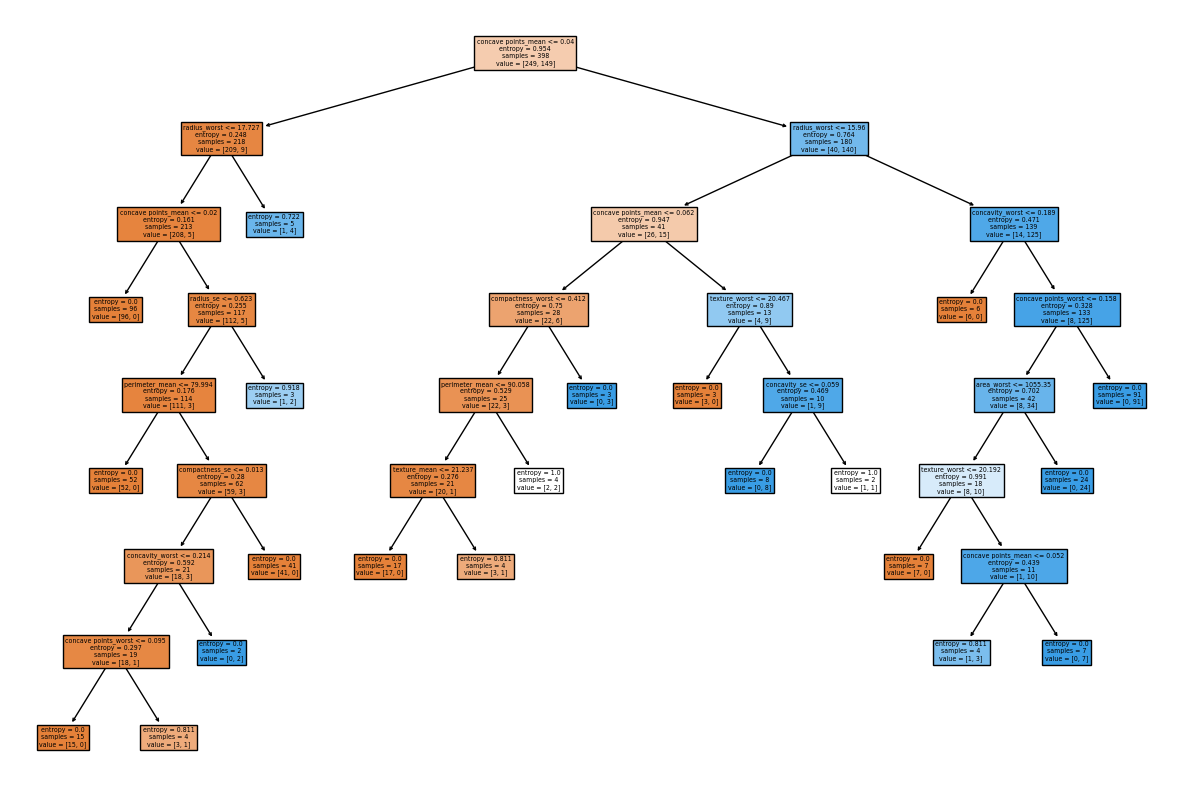

In [49]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt_clf, filled=True, feature_names = x.columns)

Read: #https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

In [50]:
pruning_path = dt_clf.cost_complexity_pruning_path(xtrain, ytrain) # clf = DecisionTreeClassifier  
ccp_alpha_values = pruning_path.ccp_alphas 

In [51]:
ccp_alpha_values 

array([0.        , 0.00399335, 0.00604739, 0.00641958, 0.00675868,
       0.00862793, 0.01202884, 0.01435018, 0.0173026 , 0.01763119,
       0.03099137, 0.03549229, 0.04094249, 0.05496803, 0.08343007,
       0.47242814])

In [52]:
clfs_list = []  # save models with diffrent ccp_alpha value
for ccp in ccp_alpha_values:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    clf.fit(xtrain, ytrain)
    clfs_list.append(clf)

In [53]:
clfs_list 

[DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.003993352659045518, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006047387516658223, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006419576589874848, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006758683256012092, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.00862793379793314, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.012028844403926979, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.014350184435176862, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.017302601474775314, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.01763119048807507, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.030991367208617764, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.03549229443392196, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.04094249107720667, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.05496803084950469, random_state=42),
 

In [54]:
train_scores = [ clf.score(xtrain, ytrain) for clf in clfs_list ] 
test_scores = [ clf.score(xtest, ytest) for clf in clfs_list ] 

In [55]:
train_scores

[1.0,
 0.992462311557789,
 0.9899497487437185,
 0.9874371859296482,
 0.9874371859296482,
 0.9824120603015075,
 0.9698492462311558,
 0.9698492462311558,
 0.9422110552763819,
 0.9422110552763819,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.6256281407035176]

In [56]:
test_scores

[0.9415204678362573,
 0.9590643274853801,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9590643274853801,
 0.9590643274853801,
 0.9298245614035088,
 0.9298245614035088,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.631578947368421]

In [57]:
import matplotlib.pyplot as plt

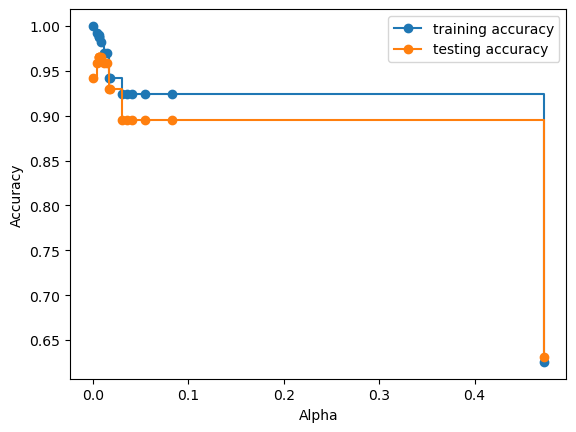

In [58]:
fig, ax = plt.subplots()
ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")

ax.plot(ccp_alpha_values, train_scores, marker='o', label="training accuracy", drawstyle="steps-post")
ax.plot(ccp_alpha_values, test_scores, marker='o', label="testing accuracy", drawstyle="steps-post")
ax.legend()

In [65]:
clf = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01)
clf.fit(xtrain, ytrain)

DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)

In [66]:
pred = clf.predict(xtest)
accuracy_score(ytest, pred)

0.9649122807017544

In [67]:
clf.score(xtrain, ytrain)

0.9824120603015075

[Text(0.4230769230769231, 0.9, 'concave points_mean <= 0.051\ngini = 0.468\nsamples = 398\nvalue = [249, 149]'),
 Text(0.15384615384615385, 0.7, 'radius_worst <= 16.83\ngini = 0.1\nsamples = 245\nvalue = [232, 13]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.043\nsamples = 230\nvalue = [225, 5]'),
 Text(0.23076923076923078, 0.5, 'texture_mean <= 16.19\ngini = 0.498\nsamples = 15\nvalue = [7, 8]'),
 Text(0.15384615384615385, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.6923076923076923, 0.7, 'texture_worst <= 20.405\ngini = 0.198\nsamples = 153\nvalue = [17, 136]'),
 Text(0.5384615384615384, 0.5, 'radius_worst <= 18.145\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.46153846153846156, 0.3, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.6153846153846154, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8461538461538461, 0.5, 'area_worst <= 718.65\ngini = 0.096\nsamples = 139\n

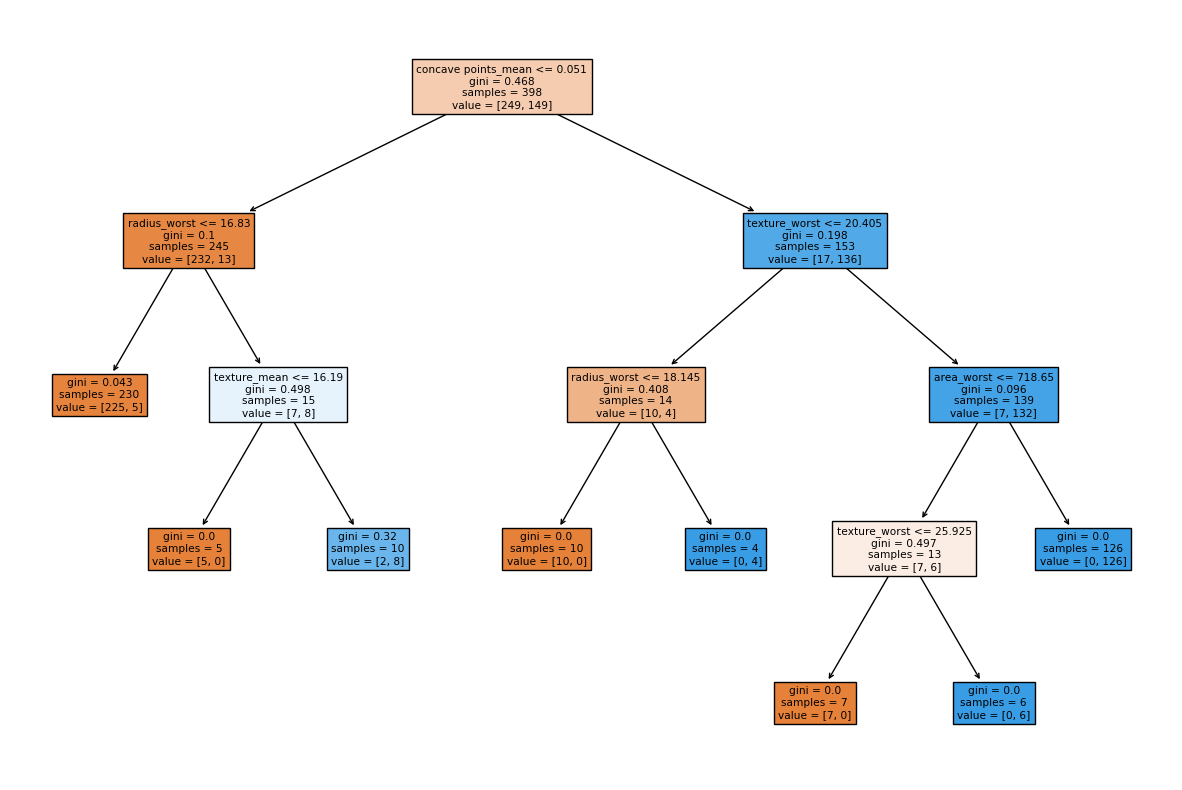

In [68]:
plt.figure(figsize=(15,10))
tree.plot_tree(clf, filled=True, feature_names = x.columns)

# XGBoost

In [ ]:
# random & grid
# before performance & after performance

In [ ]:
# xtrain, xtest, ytrain, ytest

In [ ]:
#!pip install xgboost

# ADA Boost

In [ ]:
# random & grid
# before performance & after performance

# CatBoost

In [ ]:
# random & grid
# before performance & after performance